# Speedups with full observations: "Gradient-matching" vs pseudo-marginal MCMC

This tutorial compares two approaches for learning SDEs when we have **fully observed** states with **low observation noise** and **high-frequency measurements** (so observations approach exact state measurements, i.e. Dirac):

1. **EnKF + NUTS** (filtering-based continuous-time): Uses `Filter` with EnKF to approximate the marginal likelihood, then NUTS for MCMC.

1. **Gradient-matching**: Discretizes the SDE (Euler-Maruyama), treats observations as exact states (`DiracIdentityObservation`), and runs NUTS directly on all states and parameters. This avoids filtering entirely and is typically much faster. This approach loses accuracy when the following assumptions fail to hold:
    - **Fully observed**: $y_t = x_t$ (or $y_t \approx x_t$ with low noise)
    - **Low noise**: $R = 0.01^2 I_3$ (approaches Dirac)
    - **High-frequency**: $\Delta t = 0.01$ over $[0, 20]$

The speedup comes from data-conditioned independendence of the Euler-Maruyama increments induced by these assumptions---this independence allows us to vectorize (stack) all time-steps together and form a more traditional regression problem.



We report timing and posteriors for both approaches.

## Setup and Model

We use the Lorenz 63 system with:
- **Learn**: $\rho \sim \mathcal{U}(10, 40)$

In [1]:
import time

import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DiracIdentityObservation,
    DiscreteTimeSimulator,
    Discretizer,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    SDESimulator,
)

In [2]:
def l63_fully_observed_model(
    dirac_observation: bool = False, obs_times=None, obs_values=None
):
    """Model that samples drift parameter rho and uses it in dynamics.

    Default is noisy Gaussian, full-state observations.
    If `dirac_observation=True`, uses Dirac observations (y_t = x_t)

    """
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))

    state_dim = 3
    observation_dim = state_dim
    observation_model = (
        DiracIdentityObservation()
        if dirac_observation
        else LinearGaussianObservation(
            H=jnp.eye(observation_dim, state_dim), R=jnp.eye(state_dim)
        )
    )
    # Create the dynamical model with sampled rho
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim), covariance_matrix=20.0**2 * jnp.eye(state_dim)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            ),
            diffusion_coefficient=lambda x, u, t: jnp.eye(state_dim),
        ),
        observation_model=observation_model,
    )

    # Return a sampled dynamical model, named "f".
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)

## Generate Synthetic Data

We simulate the L63 SDE and add small Gaussian noise to get observations. With low noise, these approach the true states.

Observations shape: (2000, 3)
True rho: 28.0


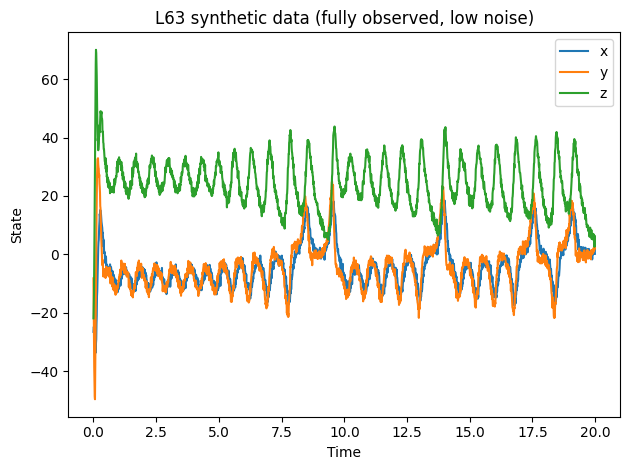

In [3]:
true_rho = 28.0
obs_times = jnp.arange(start=0.0, stop=20.0, step=0.01)  # high-frequency
rng_key = jr.PRNGKey(0)
data_init_key, data_solver_key, mcmc_key = jr.split(rng_key, 3)

true_params = {"rho": jnp.array(true_rho)}
predictive = Predictive(
    l63_fully_observed_model,
    params=true_params,
    num_samples=1,
    exclude_deterministic=False,
)

with SDESimulator():
    synthetic = predictive(data_init_key, predict_times=obs_times)

obs_values = synthetic["f_observations"].squeeze(0)  # (T, 3)
states = synthetic["f_states"].squeeze(0)  # (T, 3)

print(f"Observations shape: {obs_values.shape}")
print(f"True rho: {true_rho}")

# plot the data
obs_t = jnp.asarray(obs_times).squeeze()
for i, label in enumerate(["x", "y", "z"]):
    plt.plot(obs_t, jnp.asarray(obs_values)[:, i], label=label)
plt.xlabel("Time")
plt.ylabel("State")
plt.legend()
plt.title("L63 synthetic data (fully observed, low noise)")
plt.tight_layout()
plt.show()

In [4]:
num_samples = 100
num_warmup = 100

## Approach 2: **Gradient-matching**

Discretizes the SDE via Euler-Maruyama, uses `DiracIdentityObservation` (y_t = x_t), and runs NUTS. No filter needed.

In [5]:
# For Dirac, we condition on the states (or low-noise obs as proxy for states)
# With low noise, obs_values ≈ states; Dirac treats them as exact.
with DiscreteTimeSimulator():
    with Discretizer():
        mcmc_dirac = MCMC(
            NUTS(l63_fully_observed_model),
            num_samples=num_samples,
            num_warmup=num_warmup,
        )

        mcmc_key_dirac = jr.PRNGKey(1)
        t0 = time.perf_counter()
        mcmc_dirac.run(
            mcmc_key_dirac,
            obs_times=obs_times,
            obs_values=obs_values,
            dirac_observation=True,
        )
        t_dirac = time.perf_counter() - t0

posterior_dirac = mcmc_dirac.get_samples()
print(f"Discretizer + Dirac + NUTS: {t_dirac:.2f} seconds")

# print true vs posterior
print("Posterior summary (rho):")
print("Dirac:")
print(
    f"  mean = {float(posterior_dirac['rho'].mean()):.2f}, std = {float(posterior_dirac['rho'].std()):.2f}"
)
print(f"\nTrue rho: {true_rho}")

sample: 100%|██████████| 200/200 [00:00<00:00, 295.72it/s, 7 steps of size 3.24e-01. acc. prob=0.96] 

Discretizer + Dirac + NUTS: 2.32 seconds
Posterior summary (rho):
Dirac:
  mean = 27.55, std = 0.03

True rho: 28.0


## Approach 1: **EnKF + NUTS** (pseudo-marginal MCMC)

Uses the continuous-discrete filter (EnKF) to approximate the marginal likelihood, then NUTS MCMC.

In [6]:
from dynestyx.inference.filters import ContinuousTimeEnKFConfig

with Filter(filter_config=ContinuousTimeEnKFConfig(n_particles=25)):
    mcmc_enkf = MCMC(
        NUTS(l63_fully_observed_model), num_samples=num_samples, num_warmup=num_warmup
    )

    t0 = time.perf_counter()
    mcmc_enkf.run(
        mcmc_key, obs_times=obs_times, obs_values=obs_values, dirac_observation=False
    )
    t_enkf = time.perf_counter() - t0

posterior_enkf = mcmc_enkf.get_samples()
print(f"EnKF + NUTS: {t_enkf:.2f} seconds")

sample: 100%|██████████| 200/200 [02:32<00:00,  1.31it/s, 5 steps of size 3.15e-01. acc. prob=0.98] 

EnKF + NUTS: 158.62 seconds


## Comparison

In [7]:
print("=" * 50)
print("TIMING")
print("=" * 50)
print(f"EnKF + NUTS:                    {t_enkf:.2f} s")
print(f"Discretizer + Dirac + NUTS:     {t_dirac:.2f} s")
print(f"Speedup: {t_enkf / t_dirac:.1f}x")
print("=" * 50)

# print mean and std of rho from both posteriors
print("=" * 50)
print("POSTERIOR SUMMARY")
print("=" * 50)
print("EnKF:")
print(
    f"  mean = {float(posterior_enkf['rho'].mean()):.2f}, std = {float(posterior_enkf['rho'].std()):.2f}"
)
print("Dirac:")
print(
    f"  mean = {float(posterior_dirac['rho'].mean()):.2f}, std = {float(posterior_dirac['rho'].std()):.2f}"
)
print(f"\nTrue rho: {true_rho}")

TIMING
EnKF + NUTS:                    158.62 s
Discretizer + Dirac + NUTS:     2.32 s
Speedup: 68.5x
POSTERIOR SUMMARY
EnKF:
  mean = 27.99, std = 0.04
Dirac:
  mean = 27.55, std = 0.03

True rho: 28.0


Note that the speedup scales with T (number of observations), so a 10x longer timeseries would experience ~10x further speedup using Discretizer + Dirac. Feel free to experiment